In [ ]:
# Iván Andrés Trujillo
# ivantrujillo1229@gmail.com

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

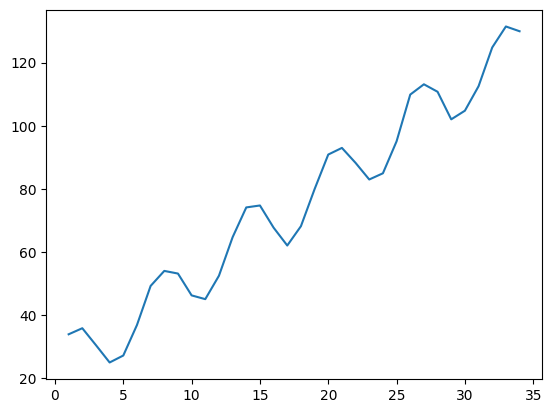

In [ ]:
# modelling seasonality, trend and residuals!
t = np.arange(1,35)
trend = t * 3.1
seasonality = 10 +  np.sin(t) * 10
residual = np.random.normal(loc = 10, scale =1, size = len(t))
y_additive = trend + seasonality + residual # Additive model!
plt.plot(t,y_additive)

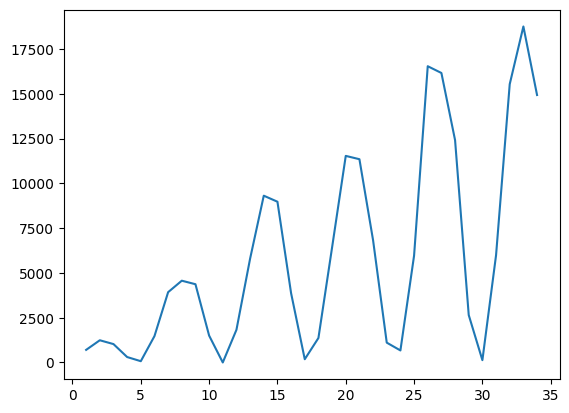

In [ ]:
# multiplicative model
y_multiplicative = trend * seasonality * residual
plt.plot(t,y_multiplicative)

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
decompose = seasonal_decompose(y_additive,
                               model='additive',
                               period=12)

In [ ]:
print(decompose.trend)
print(decompose.seasonal)
print(decompose.resid)

[         nan          nan          nan          nan          nan
          nan  42.00456303  44.8836695   48.32620152  51.9538562
  55.18890753  57.94833084  60.53342877  63.35045531  66.54854974
  69.95969918  73.2916735   76.2265994   78.84762752  81.60586412
  84.6983541   88.09560557  91.55874302  94.7521875   97.6378825
 100.41236105 103.4318045  106.77603641          nan          nan
          nan          nan          nan          nan]
[  0.66283024  10.00332029   8.83455971   0.75361559 -11.38028129
  -8.18810758   4.01927087   9.06463218   6.43038111  -2.92210035
  -9.49866565  -7.77945512   0.66283024  10.00332029   8.83455971
   0.75361559 -11.38028129  -8.18810758   4.01927087   9.06463218
   6.43038111  -2.92210035  -9.49866565  -7.77945512   0.66283024
  10.00332029   8.83455971   0.75361559 -11.38028129  -8.18810758
   4.01927087   9.06463218   6.43038111  -2.92210035]
[            nan             nan             nan             nan
             nan             nan  3.1

In [ ]:
decompose = seasonal_decompose(y_multiplicative, model = 'multiplicative', period=12)
print(decompose.trend)
print(decompose.seasonal)
print(decompose.resid)

[          nan           nan           nan           nan           nan
           nan 1962.65944354 2511.22584571 3178.67686717 3658.21457227
 3811.18141898 3811.39732829 3911.26091725 4305.84742937 4887.00966661
 5399.50847761 5667.35030406 5665.4801413  5624.37918334 5932.48191491
 6533.14653317 7188.82914995 7647.79605566 7698.9914455  7629.23065147
 7777.90926671 8253.53884815 8900.19165445           nan           nan
           nan           nan           nan           nan]
[1.08289911 2.05119147 1.81480211 1.00936957 0.03061506 0.2308261
 1.50288035 1.79925851 1.48805064 0.65018709 0.0692714  0.2706486
 1.08289911 2.05119147 1.81480211 1.00936957 0.03061506 0.2308261
 1.50288035 1.79925851 1.48805064 0.65018709 0.0692714  0.2706486
 1.08289911 2.05119147 1.81480211 1.00936957 0.03061506 0.2308261
 1.50288035 1.79925851 1.48805064 0.65018709]
[           nan            nan            nan            nan
            nan            nan 1.33069359e+00 1.01043594e+00
 9.23666003e-01 6.

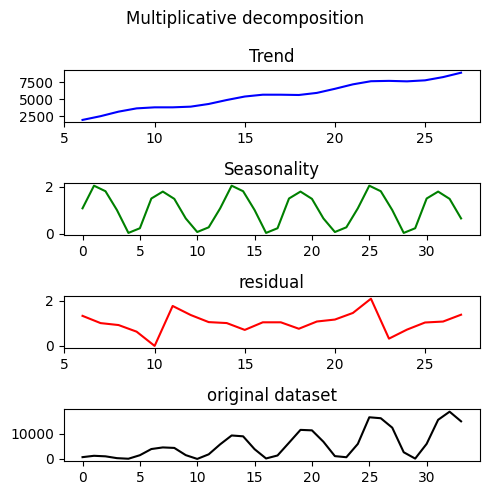

In [ ]:

# Create figure and subplots with three rectangular plots side by side
fig, axs = plt.subplots(4, 1, figsize=(5, 5))  # 3 row, 1 columns

# Plot in each rectangle
axs[0].plot(decompose.trend, color='blue')
axs[0].set_title("Trend")

axs[1].plot(decompose.seasonal, color= 'green')
axs[1].set_title("Seasonality")

axs[2].plot(decompose.resid, color='red')
axs[2].set_title("residual")

axs[3].plot(y_multiplicative, color='black')
axs[3].set_title("original dataset")

# Overall title
fig.suptitle("Multiplicative decomposition")

# Adjust layout
plt.tight_layout()
plt.show()


In [ ]:
y_additive

array([ 33.84735564,  35.7714669 ,  30.3903529 ,  24.90814003,
        27.11734092,  36.78938624,  49.18599579,  53.94745349,
        53.11047402,  46.18402477,  44.99307631,  52.41677922,
        64.63317589,  74.084202  ,  74.69838614,  67.6638192 ,
        62.00289355,  68.12999316,  79.88773918,  90.85434718,
        92.95784651,  88.20423897,  82.94024561,  84.90783156,
        95.04679854, 109.86825762, 113.13409019, 110.76215025,
       102.01986135, 104.7556929 , 112.51871938, 124.81085236,
       131.46798398, 129.95566731])

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

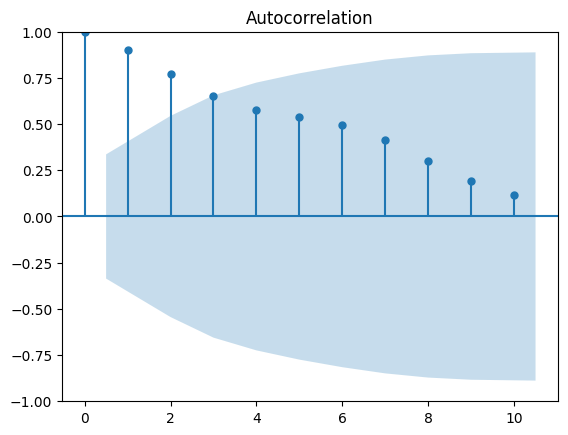

In [ ]:
plot_acf(y_additive, lags=10);

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import acf
df = pd.DataFrame(y_additive, columns = ['y'])
lag = 2
df['y-2'] = df['y'].shift(2)
mean = df['y'].mean()
df['y_z'] = df['y'] - mean
df['y_2z'] = df['y-2'] - mean

In [ ]:
df

,y,y-2,y_z,y_2z
0,33.847356,NaN,-41.269310,NaN
1,35.771467,NaN,-39.345199,NaN
2,30.390353,33.847356,-44.726313,-41.269310
3,24.908140,35.771467,-50.208526,-39.345199
4,27.117341,30.390353,-47.999325,-44.726313
5,36.789386,24.908140,-38.327280,-50.208526
6,49.185996,27.117341,-25.930670,-47.999325
7,53.947453,36.789386,-21.169212,-38.327280
8,53.110474,49.185996,-22.006192,-25.930670
9,46.184025,53.947453,-28.932641,-21.169212


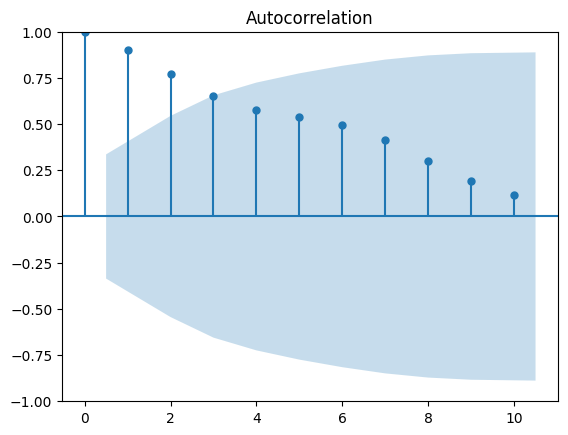

In [ ]:
plot_acf(df['y'], lags=10);

In [ ]:
np.sum(df.loc[lag:, 'y_z'].to_numpy() * df.loc[lag:, 'y_2z'].to_numpy()) / np.sum((df['y']- mean )**2)

np.float64(0.7687710571969446)

In [ ]:
acf(df['y'], nlags=lag, fft=False)[lag]

np.float64(0.7687710571969447)

In [ ]:
# why is importnat this??
# we need de-trend before apply (makes sense?)
# remember that the value with self is one (lag = 0)

# this plot is importat?

whith this graph we can determine the appropiate lag  (p) in an AR(p) model, also in ARIMA(p,d,q).


important take in mind this apply to a stationary serie.